In [25]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt


from src.visualization.plot_slices import plot_slices

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
full_preprocessed_dicoms_folder_dir = r"/home/macraedc/data/preprocessed_OS_dataset_2mm"
full_preprocessed_dicoms_folder_dir = r"/home/macraedc/data/dataset_full_renamed"
#sagittal_plots_output_dir = "D:\DANIEL\processed_croppingnew\sagittal_plots"
# os.makedirs(sagittal_plots_output_dir, exist_ok=True)

all_patientIDs = os.listdir(full_preprocessed_dicoms_folder_dir)
len(all_patientIDs)

1725

In [21]:
# Helper functions to convert from the axial view to sagittal or coronal views


def convert_to_sagittal(arr):
    sagittal_view = np.transpose(arr, (2, 1, 0))           # make sagittal view the first axis
    sagittal_view_rotated = np.rot90(sagittal_view, 1, axes=(1, 2))  # rotate the view
    return sagittal_view_rotated


def convert_to_coronal(arr):
    coronal_view = np.transpose(arr, (1, 2, 0))             # make coronal view the first axis
    coronal_view_rotated = np.rot90(coronal_view, 1, axes=(1, 2))   # rotate the view
    return coronal_view_rotated


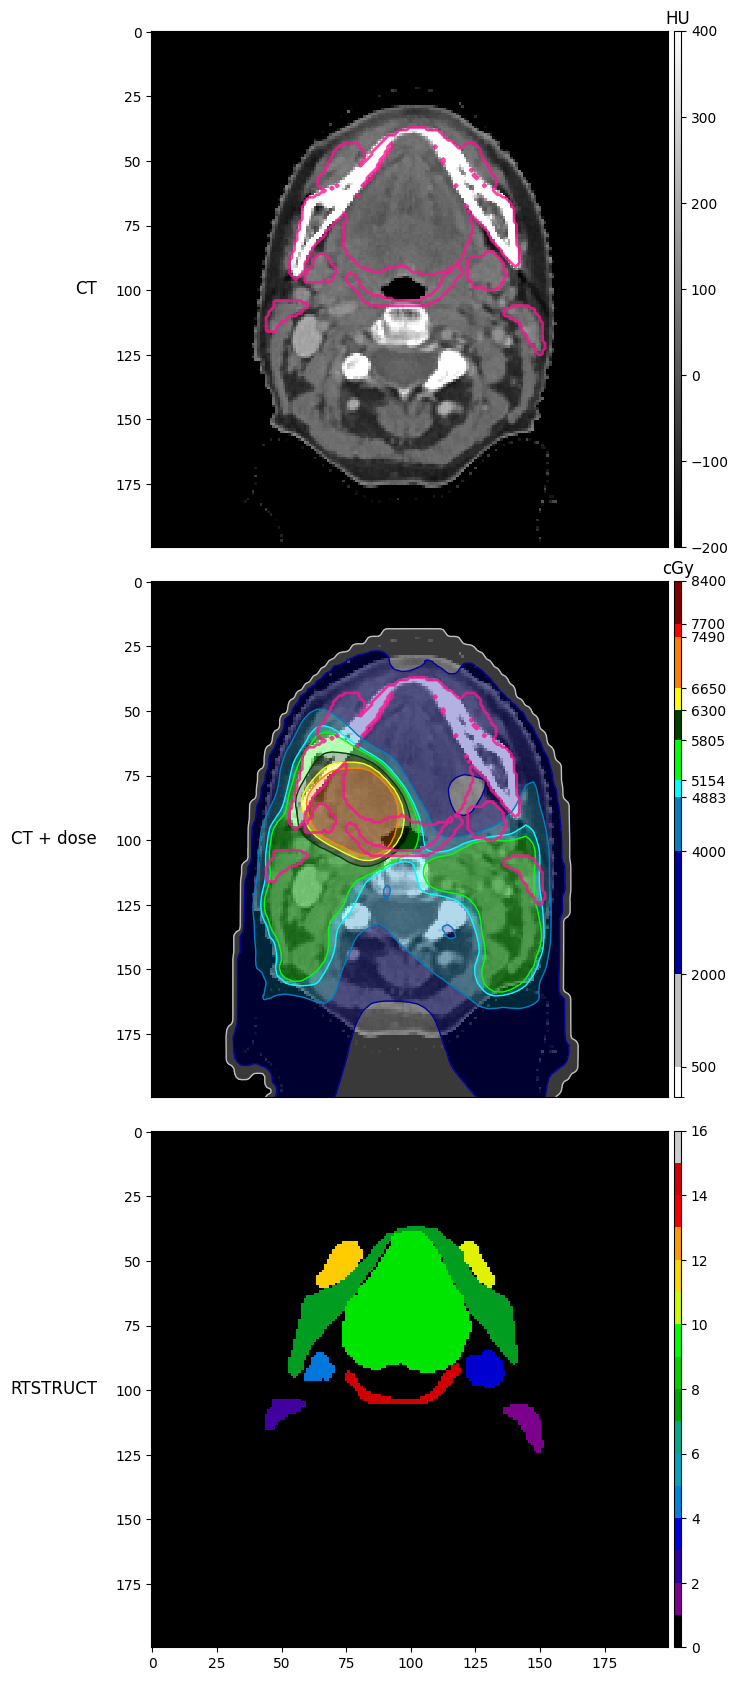

In [95]:
full_preprocessed_dicoms_folder_dir = r"/home/macraedc/data/dataset_full_renamed"
#sagittal_plots_output_dir = "D:\DANIEL\processed_croppingnew\sagittal_plots"
# os.makedirs(sagittal_plots_output_dir, exist_ok=True)

all_patientIDs = os.listdir(full_preprocessed_dicoms_folder_dir)
len(all_patientIDs)

for patientID in all_patientIDs[:1]:
    patient_dir = os.path.join(full_preprocessed_dicoms_folder_dir, patientID)

    CT_dir = os.path.join(patient_dir, "ct.npy")
    #PET_dir = os.path.join(patient_dir, "pet.npy")
    RTDOSE_dir = os.path.join(patient_dir, "rtdose.npy")
    RTSTRUCT_dir = os.path.join(patient_dir, "segmentation_map.npy")

    #patient_slices = os.listdir(patient_dir)
    CT_arr = np.load(CT_dir)[0]
    #PET_arr = np.load(PET_dir)
    RTDOSE_arr = np.load(RTDOSE_dir)[0]
    RTSTRUCT_arr = np.load(RTSTRUCT_dir)[0]

    # CT_sagittal = np.transpose(CT_arr, (2,1,0))
    """CT_sagittal_rotated =  convert_to_sagittal(CT_arr)

    #RTDOSE_sagittal = np.transpose(RTDOSE_arr, (2,1,0))
    RTDOSE_sagittal_rotated =  convert_to_sagittal(RTDOSE_arr)

    #RTSTRUCT_sagittal = np.transpose(RTSTRUCT_arr, (2,1,0))
    RTSTRUCT_sagittal_rotated =  convert_to_sagittal(RTSTRUCT_arr)
    """
    #plt.imshow(CT_sagittal_rotated[50,:, :], cmap='gray')
    #plt.show()

    pltting_dict = [{
        "Label" : "CT",
        "CT" : CT_arr,
        "RTSTRUCT" : RTSTRUCT_arr,
    },
    {
        "Label" : "CT + dose",
        "RTSTRUCT" : RTSTRUCT_arr,
        #"PET" : PET_arr,
        "CT" : CT_arr,
        "RTDOSE" : RTDOSE_arr,
    },
    {
        "Label" : "RTSTRUCT",
        "RTSTRUCT" : RTSTRUCT_arr,
        #"PET" : PET_arr,
        #"CT" : CT_arr,
        #"RTDOSE" : RTDOSE_arr,
    }]

    fig, axes = plot_slices(pltting_dict, slice_indexes=[65])  # NOTE: hardcoded to do the middle slice, which is 50 for the high-res HNC patients

    # file_save_dir = os.path.join(sagittal_plots_output_dir, patientID + ".png")
    # fig.savefig(file_save_dir, bbox_inches='tight')

    plt.plot()


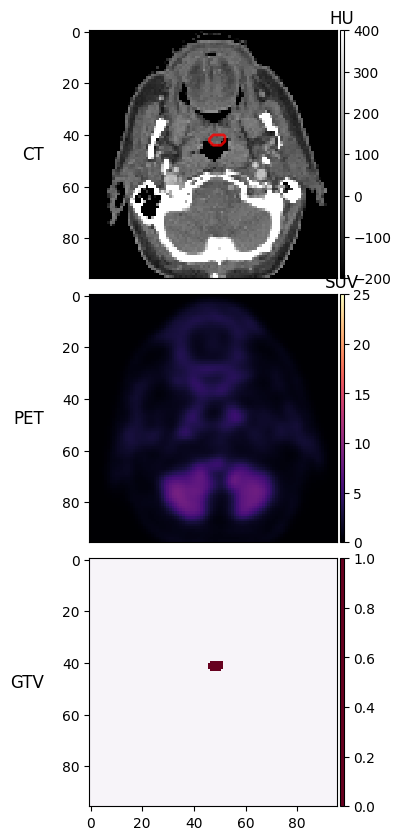

In [94]:
full_preprocessed_dicoms_folder_dir = r"/home/macraedc/data/preprocessed_OS_dataset_2mm"
#sagittal_plots_output_dir = "D:\DANIEL\processed_croppingnew\sagittal_plots"
# os.makedirs(sagittal_plots_output_dir, exist_ok=True)

all_patientIDs = os.listdir(full_preprocessed_dicoms_folder_dir)
len(all_patientIDs)

for patientID in all_patientIDs[1:2]:
    patient_dir = os.path.join(full_preprocessed_dicoms_folder_dir, patientID)

    CT_dir = os.path.join(patient_dir, "ct.npy")
    PET_dir = os.path.join(patient_dir, "pet.npy")
    #RTDOSE_dir = os.path.join(patient_dir, "rtdose.npy")
    #RTSTRUCT_dir = os.path.join(patient_dir, "segmentation_map.npy")

    #patient_slices = os.listdir(patient_dir)
    CT_arr = np.load(CT_dir)
    PET_arr = np.load(PET_dir)
    GTV_arr = np.load(os.path.join(patient_dir, "gtv_total.npy"))

    # CT_sagittal = np.transpose(CT_arr, (2,1,0))
    """CT_sagittal_rotated =  convert_to_sagittal(CT_arr)

    #RTDOSE_sagittal = np.transpose(RTDOSE_arr, (2,1,0))
    RTDOSE_sagittal_rotated =  convert_to_sagittal(RTDOSE_arr)

    #RTSTRUCT_sagittal = np.transpose(RTSTRUCT_arr, (2,1,0))
    RTSTRUCT_sagittal_rotated =  convert_to_sagittal(RTSTRUCT_arr)
    """
    #plt.imshow(CT_sagittal_rotated[50,:, :], cmap='gray')
    #plt.show()

    pltting_dict = [{
        "Label" : "CT",
        "CT" : CT_arr,
        #"RTDOSE" : RTDOSE_arr[:, ::2, ::2],
        "GTV" : GTV_arr,
        #"RTSTRUCT" : RTSTRUCT_arr,
    },
    {
        "Label" : "PET",
        #"CT" : CT_arr,
        #"RTSTRUCT" : RTSTRUCT_arr,
        #"PET" : PET_arr,
        "PET" : PET_arr,
        #"RTDOSE" : RTDOSE_arr,
    },
    {
        "Label" : "GTV",
        "GTV" : GTV_arr,
        #"PET" : PET_arr,
        #"CT" : CT_arr,
        #"RTDOSE" : RTDOSE_arr,
    }]

    fig, axes = plot_slices(pltting_dict, slice_indexes=[78])  # NOTE: hardcoded to do the middle slice, which is 50 for the high-res HNC patients

    # file_save_dir = os.path.join(sagittal_plots_output_dir, patientID + ".png")
    # fig.savefig(file_save_dir, bbox_inches='tight')

    plt.plot()


In [74]:
PET_arr.max()

14.39334774017334

In [46]:
GTV_arr.max()

1.0

In [44]:
import optuna
import time
import multiprocessing

def objective(trial):
    print(f"Trial ID: {trial.number}")
    num_cores = multiprocessing.cpu_count()
    print(f"Number of available cores: {num_cores}")
    # Define the hyperparameters to tune
    lr = trial.suggest_loguniform('lr', 1e-5, 1e-1)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    
    # Simulate training and validation
    accuracy = (0.1 / lr) * (batch_size / 32)  # Dummy formula for illustration

    time.sleep(5)
    print(f"Trial ID: {trial.number}")
    
    return accuracy

# Create a study
study = optuna.create_study(direction='maximize')

# Optimize the study with parallel trials
study.optimize(objective, n_trials=100, n_jobs=2)

# Print the best trial
print(f"Best trial: {study.best_trial.value}")
print(f"Best hyperparameters: {study.best_trial.params}")

[I 2025-01-29 08:56:51,145] A new study created in memory with name: no-name-a8841236-5eef-4ac2-8e57-e1fb862aa75c
C:\Users\S.P.M. de Vette\AppData\Local\Temp\ipykernel_32480\538234850.py:10: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('lr', 1e-5, 1e-1)


Trial ID: 0
Number of available cores: 32
Trial ID: 1
Number of available cores: 32


[I 2025-01-29 08:56:56,165] Trial 0 finished with value: 0.523989999649002 and parameters: {'lr': 0.09542166841636829, 'batch_size': 16}. Best is trial 0 with value: 0.523989999649002.
[I 2025-01-29 08:56:56,165] Trial 1 finished with value: 2501.2560926579545 and parameters: {'lr': 7.995982522024382e-05, 'batch_size': 64}. Best is trial 1 with value: 2501.2560926579545.


Trial ID: 0
Trial ID: 1


KeyboardInterrupt: 

In [52]:
from multiprocessing import Manager
import random
import time

from joblib import parallel_backend
import optuna

from dask.distributed import Client, wait
from dask_cuda import LocalCUDACluster

cluster = LocalCUDACluster()
client = Client(cluster)

n_gpus = 1

class Objective:
    def __init__(self, gpu_queue):
        # Shared queue to manage GPU IDs.
        self.gpu_queue = gpu_queue

    def __call__(self, trial):
        # Fetch GPU ID for this trial.
        gpu_id = self.gpu_queue.get()

        # Please write actual objective function here.
        time.sleep(random.randint(1, 8))

        # Return GPU ID to the queue.
        self.gpu_queue.put(gpu_id)

        # GPU ID is stored as an objective value.
        print(gpu_id)
        return gpu_id

study = optuna.create_study(storage="sqlite:///example.db")

with Manager() as manager:
    
    # Initialize the queue by adding available GPU IDs.
    gpu_queue = manager.Queue()
    for i in range(n_gpus):
        gpu_queue.put(i)

    with parallel_backend("dask", n_jobs=n_gpus):
        study.optimize(Objective(gpu_queue), n_trials=10, n_jobs=n_gpus)

ImportError: Only Linux is supported by Dask-CUDA at this time

In [ ]:
from multiprocessing import Manager
import random
import time

from joblib import parallel_backend
import optuna

n_gpus = 1

class Objective:
    def __init__(self, gpu_queue):
        # Shared queue to manage GPU IDs.
        self.gpu_queue = gpu_queue

    def __call__(self, trial):
        # Fetch GPU ID for this trial.
        gpu_id = self.gpu_queue.get()

        # Please write actual objective function here.
        time.sleep(random.randint(1, 3))

        # Return GPU ID to the queue.
        self.gpu_queue.put(gpu_id)

        # GPU ID is stored as an objective value.
        print(gpu_id)
        
        return gpu_id

study = optuna.load_study(storage="sqlite:///example.db")

with Manager() as manager:
    
    # Initialize the queue by adding available GPU IDs.
    gpu_queue = manager.Queue()
    for i in range(n_gpus):
        gpu_queue.put(i)

    with parallel_backend("multiprocessing", n_jobs=n_gpus):
        study.optimize(Objective(gpu_queue), n_trials=10, n_jobs=n_gpus)

OperationalError: (MySQLdb.OperationalError) (2002, "Can't connect to server on 'localhost' (10061)")
(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [58]:
pip install mysqlclient

  Using cached mysqlclient-2.2.7-cp310-cp310-win_amd64.whl.metadata (4.8 kB)
Using cached mysqlclient-2.2.7-cp310-cp310-win_amd64.whl (207 kB)
Note: you may need to restart the kernel to use updated packages.
